#Task 10: Feature-Based Explanations (For Content-Based Filtering)

In [ ]:
!pip install shap

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Load User Ratings
r_cols = ['user_id', 'movie_id', 'rating', 'timestamp']
ratings = pd.read_csv('u.data', sep='\t', names=r_cols, encoding='latin-1')

# 2. Load Movies and Genres
m_cols = ['movie_id', 'title', 'release_date', 'video_release_date', 'imdb_url'] + \
         ['unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
          'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
          'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
movies = pd.read_csv('u.item', sep='|', names=m_cols, encoding='latin-1')

# 3. Extract Release Year
movies['release_year'] = pd.to_datetime(movies['release_date'], errors='coerce').dt.year
movies['release_year'] = movies['release_year'].fillna(movies['release_year'].median())

print("Libraries installed and data loaded!")

Libraries installed and data loaded!


In [ ]:
# 1. Select a Target User
TARGET_USER = 1
user_ratings = ratings[ratings['user_id'] == TARGET_USER]

# 2. Merge with Movie Features
user_data = user_ratings.merge(movies, on='movie_id')

# 3. Define Features (X) and Target (y)
genre_cols = movies.columns[5:24].tolist()
feature_cols = genre_cols + ['release_year']

X = user_data[feature_cols]
y = user_data['rating']

# 4. Train a Random Forest Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

print(f"Model trained successfully for User {TARGET_USER} on {len(X)} rated movies.")

Model trained successfully for User 1 on 272 rated movies.


Target Movie: So Dear to My Heart (1949)
Predicted Rating: 2.82 Stars



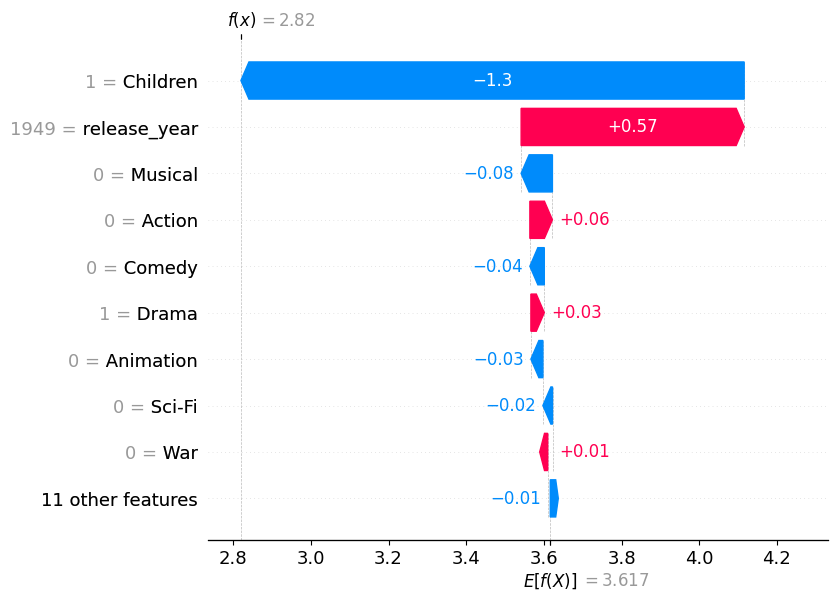

In [ ]:
# 1. Pick a movie the user HAS NOT seen to recommend
unseen_movies = movies[~movies['movie_id'].isin(user_data['movie_id'])]
sample_movie = unseen_movies.sample(1, random_state=42)
sample_features = sample_movie[feature_cols]

# 2. Predict the rating
predicted_rating = model.predict(sample_features)[0]
movie_title = sample_movie['title'].values[0]

# 3. Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer(sample_features)

print(f"Target Movie: {movie_title}")
print(f"Predicted Rating: {predicted_rating:.2f} Stars\n")
shap.plots.waterfall(shap_values[0])

In [ ]:
# Extract the SHAP values and feature names for the sample movie
values = shap_values.values[0]
feature_names = sample_features.columns

# Pair them up and sort by impact (absolute value)
feature_impacts = list(zip(feature_names, values, sample_features.values[0]))
# Filter for features that positively impacted the score
positive_features = [f for f in feature_impacts if f[1] > 0]
positive_features.sort(key=lambda x: x[1], reverse=True)

# Generate the explanation text
if positive_features:
    top_1 = positive_features[0]
    top_2 = positive_features[1] if len(positive_features) > 1 else None

    explanation = f"We highly recommend '{movie_title}'. "

    # Logic to formulate the sentence based on the feature type
    reasons = []
    for feat, impact, val in [top_1, top_2]:
        if feat is None: continue
        if feat == 'release_year':
            reasons.append(f"it is from the {int(val)}s")
        else:
            reasons.append(f"it fits your preference for {feat} movies")

    explanation += f"This movie was recommended primarily because {reasons[0]}"
    if len(reasons) > 1:
        explanation += f", and {reasons[1]}."

    print(explanation)
else:
    print(f"We recommend '{movie_title}', though it doesn't strongly match your usual distinct preferences.")

We highly recommend 'So Dear to My Heart (1949)'. This movie was recommended primarily because it is from the 1949s, and it fits your preference for Action movies.


#Task 11: Neighborhood-Based Explanations (For Collaborative Filtering)

In [ ]:
from sklearn.neighbors import NearestNeighbors

# 1. Create the User-Item Matrix
# Rows = Users, Columns = Movies, Values = Ratings (0 if unrated)
user_movie_matrix = ratings.pivot(index='user_id', columns='movie_id', values='rating').fillna(0)

# 2. Fit the k-NN Model based on User Similarity
# Using cosine similarity to measure the angle between user rating vectors
knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(user_movie_matrix)

print("User-Item Matrix created and k-NN model fitted successfully!")

User-Item Matrix created and k-NN model fitted successfully!


In [ ]:
target_user_id = 1
k_neighbors = 6

# Find the k-nearest neighbors
target_user_vector = user_movie_matrix.loc[target_user_id].values.reshape(1, -1)
distances, indices = knn_model.kneighbors(target_user_vector, n_neighbors=k_neighbors)

# Extract neighbor IDs (ignoring the first index)
neighbor_indices = indices.flatten()[1:]
neighbor_ids = user_movie_matrix.index[neighbor_indices]

# 2. Find the best movie to recommend
# Get movies the target user has already seen
target_seen_movies = ratings[ratings['user_id'] == target_user_id]['movie_id'].tolist()

# Get movies HIGHLY rated (4 or 5 stars) by the neighborhood
neighbor_ratings = ratings[(ratings['user_id'].isin(neighbor_ids)) & (ratings['rating'] >= 4)]

# Filter out movies the target user has already seen
recommendation_candidates = neighbor_ratings[~neighbor_ratings['movie_id'].isin(target_seen_movies)]

# Pick the movie most frequently rated highly by the neighbors
top_movie_id = recommendation_candidates['movie_id'].value_counts().index[0]
top_movie_title = movies[movies['movie_id'] == top_movie_id]['title'].values[0]

# 3. Formulate the Explanation (Find the shared favorite)
# Get movies the target user highly rated
target_loved = ratings[(ratings['user_id'] == target_user_id) & (ratings['rating'] >= 4)]['movie_id'].tolist()

shared_loved = neighbor_ratings[neighbor_ratings['movie_id'].isin(target_loved)]

# Pick the strongest shared movie connection
shared_movie_id = shared_loved['movie_id'].value_counts().index[0]
shared_movie_title = movies[movies['movie_id'] == shared_movie_id]['title'].values[0]

# 4. Output the Result
print("-" * 60)
print(f"RECOMMENDATION FOR USER {target_user_id}")
print("-" * 60)
print(f"Suggested Movie: {top_movie_title}")
print(f"Explanation:     Users who liked '{shared_movie_title}' also liked '{top_movie_title}'.\n")

------------------------------------------------------------
🎯 RECOMMENDATION FOR USER 1
------------------------------------------------------------
Suggested Movie: Batman (1989)
Explanation:     Users who liked 'Empire Strikes Back, The (1980)' also liked 'Batman (1989)'.



#Task 12: Model-Agnostic Explainability (For Deep Learning Models)

In [ ]:
!pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 17.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=982ce8ef626ad17570fbbff6ef0768c22ccd33234ebfb57d8f1c6f4f399e1b70
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)
global_avg = train_data['rating'].mean()

movie_avgs = train_data.groupby('movie_id')['rating'].mean().rename('movie_avg_rating')
if 'movie_avg_rating' not in movies.columns:
    movies = movies.merge(movie_avgs, on='movie_id', how='left')
movies['movie_avg_rating'] = movies['movie_avg_rating'].fillna(global_avg)

train_merged = train_data.merge(movies, on='movie_id')
genre_cols = movies.columns[5:24]
user_genre_avgs = {}
for genre in genre_cols:
    genre_specific_ratings = train_merged[train_merged[genre] == 1]
    user_genre_avgs[genre] = genre_specific_ratings.groupby('user_id')['rating'].mean()

user_features_df = pd.DataFrame(user_genre_avgs).fillna(global_avg)

TARGET_USER = 1
user_1_features = user_features_df.loc[TARGET_USER].values
feature_cols = genre_cols.tolist() + ['release_year', 'movie_avg_rating']

# We need a unified matrix of inputs for LIME
nn_inputs = []
nn_targets = []

for _, row in train_data.iterrows():
    m_id = row['movie_id']
    if m_id in movies['movie_id'].values:
        m_row = movies[movies['movie_id'] == m_id].iloc[0]

        # User Features (if it's not User 1, we just use the global avg to fill space for this demo)
        u_id = row['user_id']
        u_vec = user_features_df.loc[u_id].values if u_id in user_features_df.index else np.full(19, global_avg)

        # Movie Features
        m_vec = np.concatenate([m_row[genre_cols].values, [m_row['release_year'], m_row['movie_avg_rating']]])

        # Combine them all into one flat array of 40 features
        combined_features = np.concatenate([u_vec, m_vec])
        nn_inputs.append(combined_features)
        nn_targets.append(row['rating'])

X_train_nn = np.array(nn_inputs, dtype='float32')
y_train_nn = np.array(nn_targets, dtype='float32')

# 2. Build and Train a Simplified Deep Learning Model
print("Training Neural Network for LIME explanation...")
dl_model = Sequential([
    Dense(64, activation='relu', input_shape=(40,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

dl_model.compile(optimizer='adam', loss='mse')
dl_model.fit(X_train_nn, y_train_nn, epochs=5, batch_size=256, verbose=0)
print("Model Trained! You can now run Cell 8.")

Training Neural Network for LIME explanation...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Trained! You can now run Cell 8.


In [ ]:
# 1. Define all feature names (19 User Genres + 19 Movie Genres + Year + Avg Rating)
user_feature_names = [f"User_Pref_{g}" for g in genre_cols]
movie_feature_names = [f"Movie_Genre_{g}" for g in genre_cols] + ['Release_Year', 'Movie_Avg_Rating']
all_feature_names = user_feature_names + movie_feature_names

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_nn,
    feature_names=all_feature_names,
    class_names=['Rating'],
    mode='regression',
    random_state=42
)

sample_idx = 0
instance_to_explain = X_train_nn[sample_idx]
actual_rating = y_train_nn[sample_idx]

def predict_fn(x):
    return dl_model.predict(x).reshape(-1)

# 4. Generate the Explanation
print(f"Generating LIME explanation for Instance {sample_idx}...")
print(f"Actual Rating: {actual_rating}")
print(f"Predicted Rating: {dl_model.predict(instance_to_explain.reshape(1, -1))[0][0]:.2f}")

# Request the explanation
exp = explainer.explain_instance(
    instance_to_explain,
    predict_fn,
    num_features=10 # Show the top 10 most influential features
)

print("\n--- LIME Explanation Breakdown ---")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")


Generating LIME explanation for Instance 0...
Actual Rating: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Rating: 3.37
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

--- LIME Explanation Breakdown ---
Release_Year <= 1986.00: -0.0460
Movie_Genre_Crime <= 0.00: -0.0157
Movie_Genre_Documentary <= 0.00: -0.0141
Movie_Genre_War <= 0.00: -0.0125
Movie_Genre_Drama <= 0.00: -0.0114
Movie_Genre_Horror <= 0.00: 0.0114
3.53 < User_Pref_Documentary <= 4.00: 0.0091
Movie_Genre_Comedy <= 0.00: -0.0089
Movie_Genre_Musical <= 0.00: 0.0088
Movie_Genre_Children <= 0.00: 0.0078
